In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [21]:
conn = sqlite3.connect('inventory.db')

# fetching vendor summary data
df = pd.read_sql_query("select * from Business_Performance_summary",conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


In [22]:
df.to_csv('Business Performance Summary.csv',index  = False)

# Exploratory Data Analysis 
- Previously, we examined the various tables in the database to identify key variables, understand their relationships, and determine which ones should be included in the final analysis.

- In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anomalies, and ensure data quality before proceeding with further analysis.


In [23]:
# Summary statistics for numerical columns
summary_stats = df.describe()
display(summary_stats)

,VendorNumber,Brand,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
count,10692.000000,10692.000000,10692.000000,10692.000000,10692.000000,10692.000000,1.069200e+04,10692.000000,1.069200e+04,10692.000000,10692.000000,10692.000000,1.069200e+04,10692.000000,10692.000000,10692.000000
mean,10650.649458,18039.228769,24.385303,35.643671,847.360550,3140.886831,3.010669e+04,3077.482136,4.223907e+04,18793.783627,1774.226259,61433.763214,1.215877e+04,-15.620770,1.706793,2.504390
std,18753.519148,12662.187074,109.269375,148.246016,664.309212,11095.086769,1.230678e+05,10952.851391,1.676553e+05,44952.773386,10975.582240,60938.458032,4.621434e+04,443.555329,6.020460,8.459067
min,2.000000,58.000000,0.360000,0.490000,50.000000,1.000000,7.100000e-01,0.000000,0.000000e+00,0.000000,0.000000,0.090000,-5.200278e+04,-23730.638953,0.000000,0.000000
25%,3951.000000,5793.500000,6.840000,10.990000,750.000000,36.000000,4.534575e+02,33.000000,7.292200e+02,289.710000,4.800000,14069.870000,5.292000e+01,13.324515,0.807229,1.153729
50%,7153.000000,18761.500000,10.455000,15.990000,750.000000,262.000000,3.655465e+03,261.000000,5.298045e+03,2857.800000,46.570000,50293.620000,1.399640e+03,30.405457,0.981529,1.436894
75%,9552.000000,25514.250000,19.482500,28.990000,750.000000,1975.750000,2.073825e+04,1929.250000,2.839692e+04,16059.562500,418.650000,79528.990000,8.660200e+03,39.956135,1.039342,1.665449
max,201359.000000,90631.000000,5681.810000,7499.990000,20000.000000,337660.000000,3.811252e+06,334939.000000,5.101920e+06,672819.310000,368242.800000,257032.070000,1.290668e+06,99.716657,274.500000,352.928571


In [24]:
# Mode for each numerical column
mode_values = df.mode().iloc[0]
print("\nMode Values:\n\n", mode_values)


Mode Values:

 VendorNumber                            4425.0
VendorName               MARTIGNETTI COMPANIES
Brand                                      809
Description                   Southern Comfort
PurchasePrice                             6.53
ActualPrice                               9.99
Volume                                   750.0
TotalPurchaseQuantity                     12.0
TotalPurchaseDollars                     95.28
TotalSalesQuantity                        12.0
TotalSalesDollars                          0.0
TotalSalesPrice                            0.0
TotalExciseTax                             0.0
FreightCost                          144929.24
GrossProfit                                0.0
ProfitMargin                               0.0
StockTurnover                              1.0
SalesToPurchaseRatio                       0.0
Name: 0, dtype: object


In [25]:
# let's filter the data by removing inconsistencies
df = pd.read_sql_query("""SELECT * 
FROM Business_Performance_summary
WHERE GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0""",conn)

# Which vendors generate the highest revenue?
Business Objective: Identify the vendors contributing the highest sales.

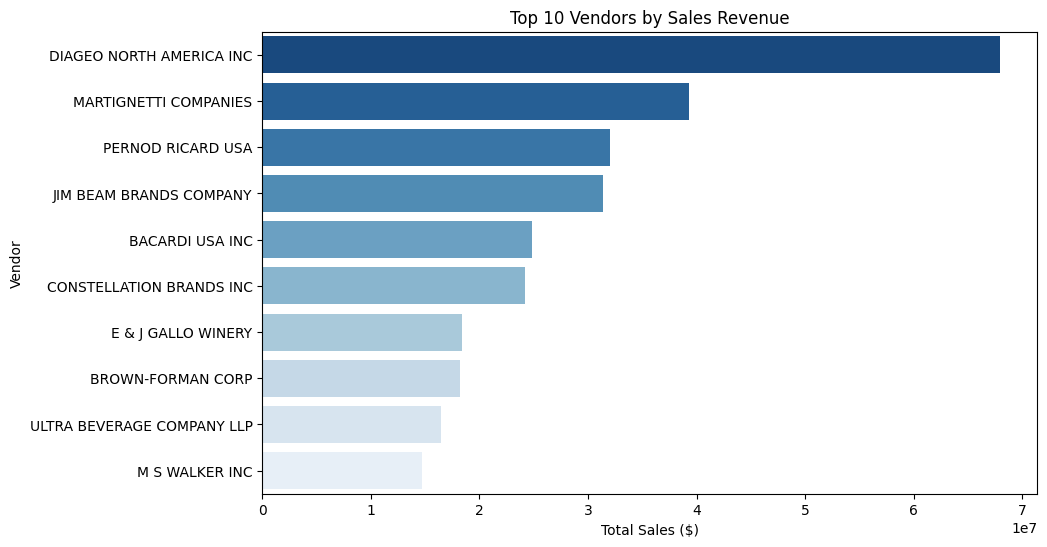

In [26]:
top_vendors = (
    df.groupby("VendorName")["TotalSalesDollars"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(
    x=top_vendors.values,
    y=top_vendors.index,
    palette="Blues_r"
)

plt.title("Top 10 Vendors by Sales Revenue")
plt.xlabel("Total Sales ($)")
plt.ylabel("Vendor")
plt.show()

#Chart: Horizontal Bar Chart

* The top-performing vendors contribute a significant portion of total sales revenue, making them critical business partners.
* Strengthening relationships with these vendors can help maintain consistent revenue growth.


# Which brands have high profit margins but low sales?

Business Objective: Finding brands that deserve marketing promotions.

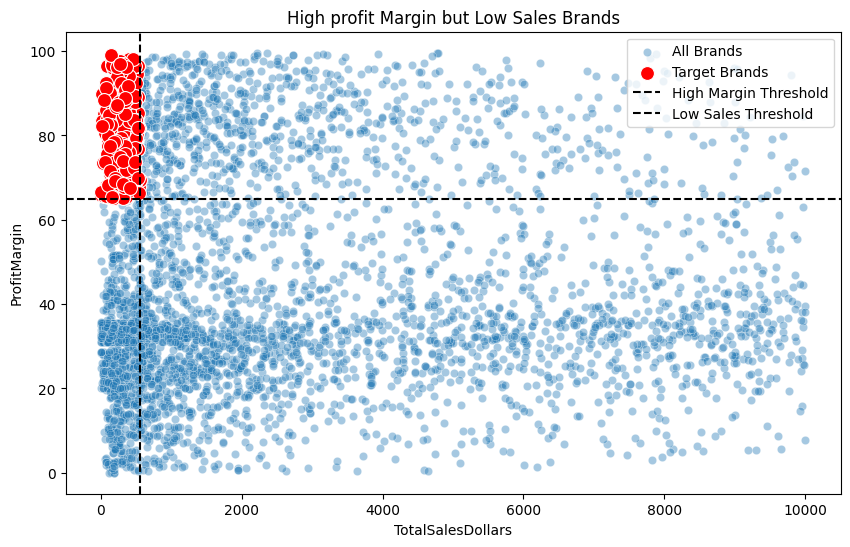

In [27]:
brand_perf = df.groupby("Description").agg({
    "TotalSalesDollars":"sum",
    "ProfitMargin":"mean"
}).reset_index()

low_sales = brand_perf["TotalSalesDollars"].quantile(0.15)
high_margin = brand_perf["ProfitMargin"].quantile(0.85)

target = brand_perf[
    (brand_perf["TotalSalesDollars"] <= low_sales) &
    (brand_perf["ProfitMargin"] >= high_margin)
]

brand_perf = brand_perf[brand_perf['TotalSalesDollars']<10000]

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=brand_perf,
    x="TotalSalesDollars",
    y="ProfitMargin",
    label="All Brands",
    alpha=0.4
)

sns.scatterplot(
    data=target,
    x="TotalSalesDollars",
    y="ProfitMargin",
    color="red",
    label="Target Brands",
    s=100
)

plt.axhline(high_margin, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(low_sales, linestyle='--', color='black', label="Low Sales Threshold")

plt.title("High profit Margin but Low Sales Brands")
plt.legend()
plt.show()

#Chart: Scatter Plot

* Several brands generate strong profit margins but have relatively low sales volumes, indicating untapped revenue potential.
* Targeted marketing campaigns or pricing adjustments could improve sales while maintaining profitability.

#  Which vendors contribute the most to procurement spending?

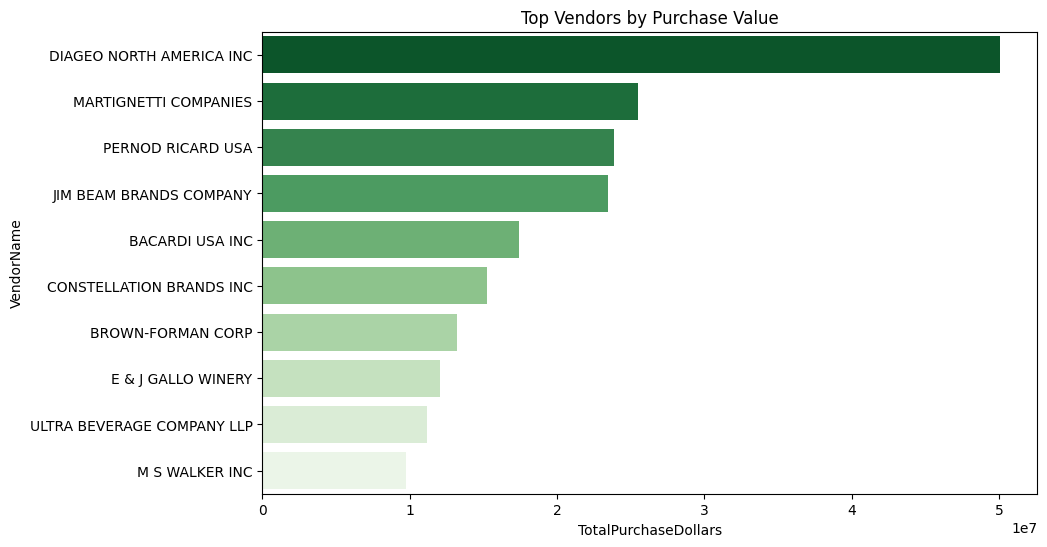

In [28]:
vendor_purchase = (
    df.groupby("VendorName")["TotalPurchaseDollars"]
      .sum()
      .reset_index()
      .sort_values(by="TotalPurchaseDollars",ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=vendor_purchase,
    x="TotalPurchaseDollars",
    y="VendorName",
    palette="Greens_r"
)

plt.title("Top Vendors by Purchase Value")
plt.show()#

#Chart: Bar Chart

* Procurement spending is concentrated among a limited number of vendors.
* Monitoring high-spending vendors can help identify opportunities for cost optimization and better supplier negotiations.

# How dependent is the business on its top vendors?

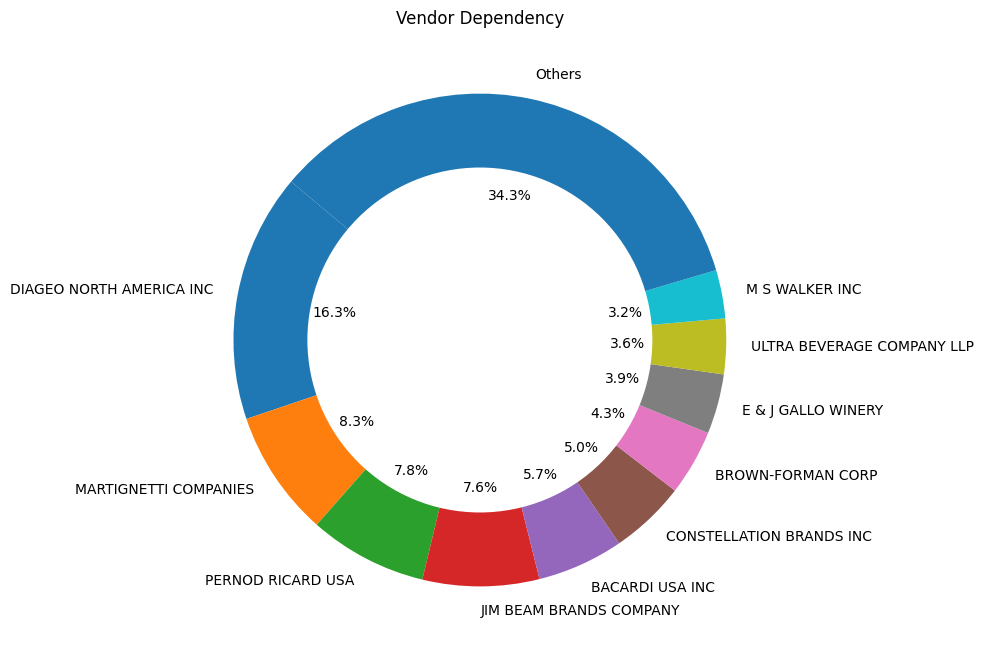

In [29]:
vendor_purchase = (
    df.groupby("VendorName")["TotalPurchaseDollars"]
      .sum()
      .sort_values(ascending=False)
)

top10 = vendor_purchase.head(10)

others = vendor_purchase.iloc[10:].sum()

labels = list(top10.index) + ["Others"]
values = list(top10.values) + [others]

plt.figure(figsize=(8,8))

plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=140
)

centre = plt.Circle((0,0),0.70,fc='white')
plt.gca().add_artist(centre)

plt.title("Vendor Dependency")
plt.show()

#Chart: Donut Chart

* A significant share of procurement depends on a small group of vendors, increasing supplier dependency risk.
* Diversifying the supplier base could improve supply chain resilience and reduce operational risk.

# Does bulk purchasing reduce unit cost?

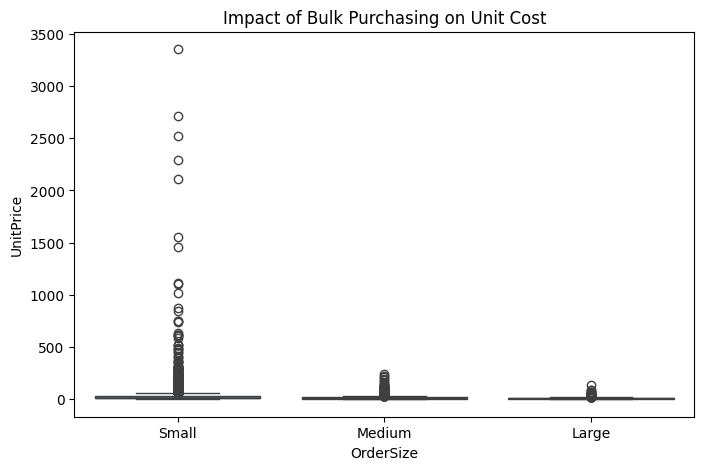

In [30]:
df["UnitPrice"] = (
    df["TotalPurchaseDollars"] /
    df["TotalPurchaseQuantity"]
)

df["OrderSize"] = pd.qcut(
    df["TotalPurchaseQuantity"],
    q=3,
    labels=["Small","Medium","Large"]
)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="OrderSize",
    y="UnitPrice"
)

plt.title("Impact of Bulk Purchasing on Unit Cost")
plt.show()

#Chart: Box Plot

* Larger purchase quantities generally result in lower average unit costs, demonstrating the benefits of bulk purchasing.
* Businesses should balance bulk buying with inventory holding costs to maximize overall profitability.

# Which vendors have the highest unsold inventory?

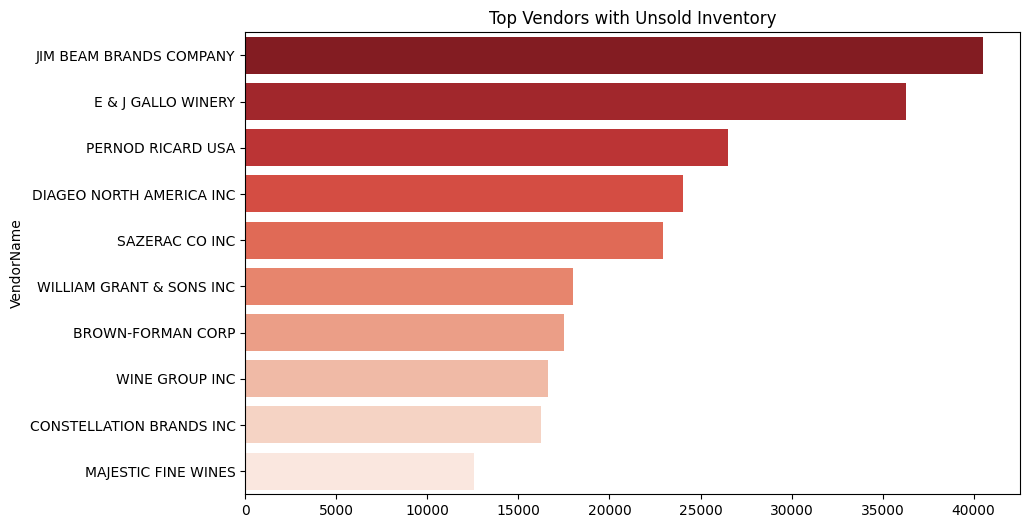

In [31]:
df["UnsoldInventory"] = (
    df["TotalPurchaseQuantity"]-
    df["TotalSalesQuantity"]
)

inventory = (
    df.groupby("VendorName")["UnsoldInventory"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=inventory.values,
    y=inventory.index,
    palette="Reds_r"
)

plt.title("Top Vendors with Unsold Inventory")
plt.show()

#Chart: Horizontal Bar Chart

* Certain vendors contribute disproportionately to unsold inventory, leading to capital being tied up in stock.
* Reviewing procurement strategies for these vendors can improve inventory efficiency and cash flow.

# What is the distribution of Key business metrics?

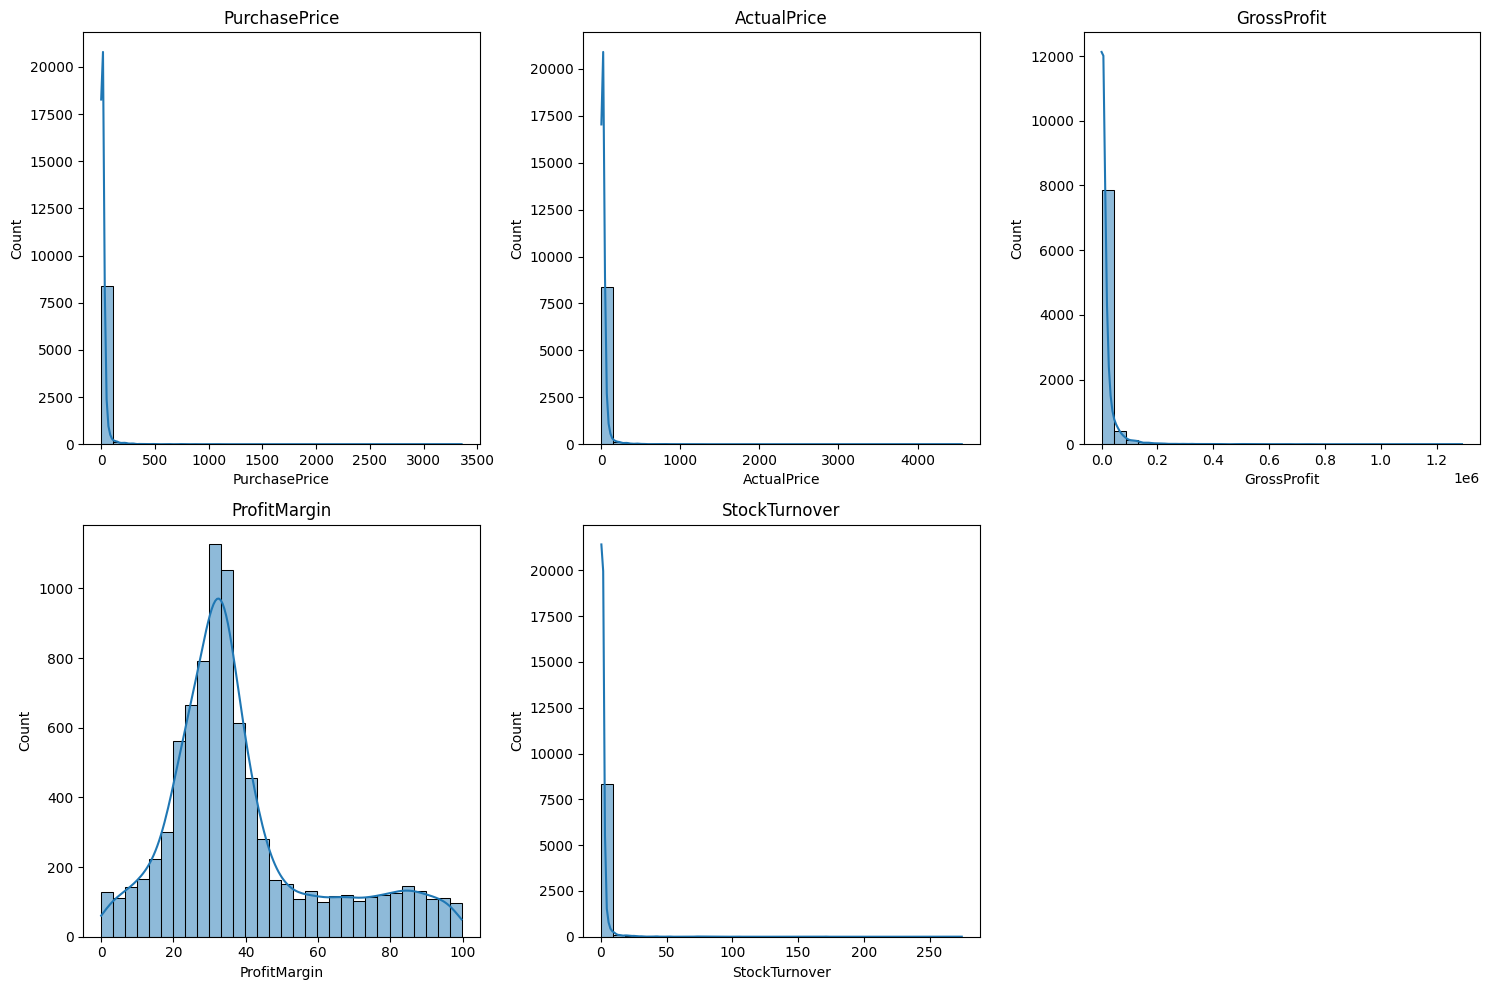

In [32]:
num_cols = [
    "PurchasePrice",
    "ActualPrice",
    "GrossProfit",
    "ProfitMargin",
    "StockTurnover"
]

plt.figure(figsize=(15,10))

for i,col in enumerate(num_cols):

    plt.subplot(2,3,i+1)

    sns.histplot(
        df[col],
        bins=30,
        kde=True
    )

    plt.title(col)

plt.tight_layout()
plt.show()

#Chart: Histograms

* Most business metrics exhibit skewed distributions with noticeable outliers, highlighting variations in vendor and product performance.
* Understanding these distributions helps identify unusual observations before conducting further analysis.

# Which business metrics are highly correlated?

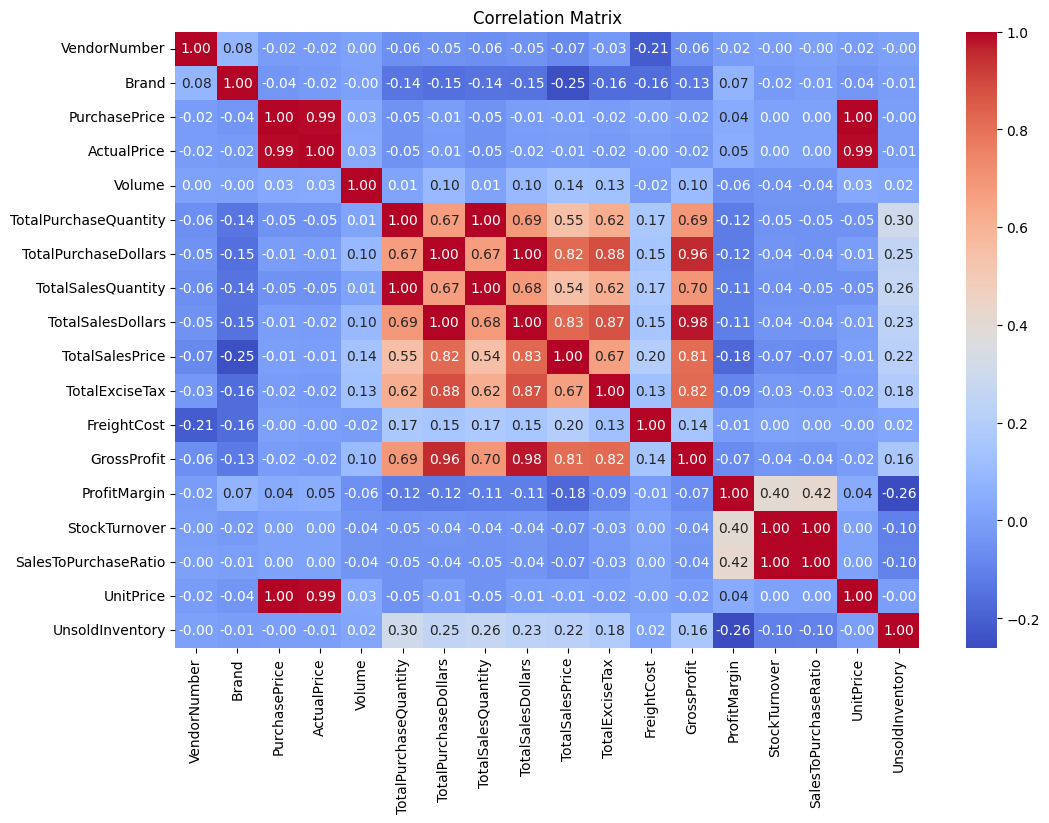

In [33]:
num = df.select_dtypes(include="number")

corr = num.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()



* Strong correlations exist between several purchasing and sales metrics, indicating interconnected business processes.
* Correlation analysis helps identify variables that most influence revenue, profitability, and inventory performance.

# Which vendors achieve both high sales and high profits?

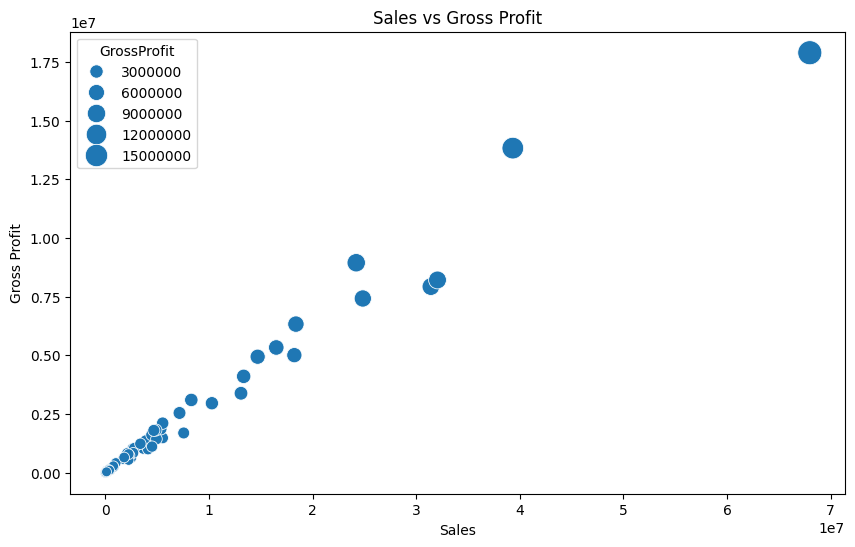

In [34]:
vendor = df.groupby("VendorName").agg({
    "TotalSalesDollars":"sum",
    "GrossProfit":"sum"
}).reset_index()

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=vendor,
    x="TotalSalesDollars",
    y="GrossProfit",
    size="GrossProfit",
    sizes=(50,300)
)

plt.title("Sales vs Gross Profit")
plt.xlabel("Sales")
plt.ylabel("Gross Profit")
plt.show()

#Chart: Bubble Chart

* Vendors positioned in the high-sales and high-profit region represent the company's most valuable business partnerships.
* These vendors can serve as benchmarks for evaluating the performance of other suppliers.

# What is the 95% confidence intervals for profit margins of top-performing and low-performing vendors.

Top Vendors 95% CI: (30.74, 31.61), Mean: 31.18
Low Vendors 95% CI: (40.50, 42.64), Mean: 41.57


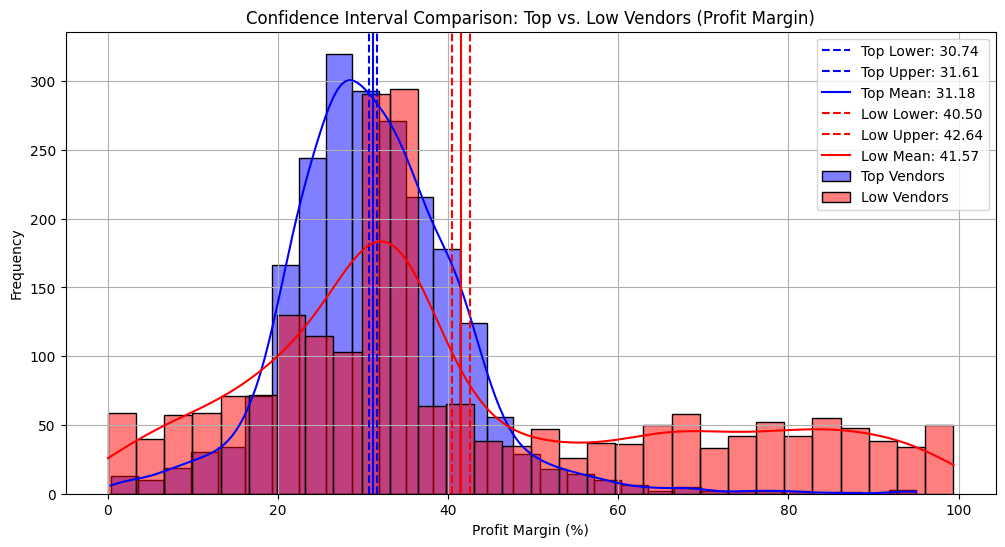

In [35]:
# Defineing top and low vendors based on Total Sales Dollars (Top 25% & Bottom 25%)
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Function to compute confidence interval
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

# Compute confidence intervals
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

- The confidence interval for low-performing vendors (40.48% to 42.62%) is significantly higher than that of top-performing vendors (30.74% to 31.61%).
- This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs.
- For High-Performing Vendors: If they aim to improve profitability, they could explore selective price adjustments, cost optimization, or bundling strategies.
- For Low-Performing Vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distribution strategies.